# Using ROSALIA to estimate stray-light in Nexus S3 stored WFI exposures

***

## What is this? 

The purpose of this notebook is to demonstrate the use of ROSALIA on the Roman Nexus cloud. We will access a pre-generated Roman mock observation, generate a ROSALIA exposure object, and then use the `rosalia.core.exposure.straylight()` method to estimate the expected stray-light background from out-of-field sources. The code will generate a series of summary plots (png images) and a background image stored as a FITS format. 

## How to start

To run this notebook, please activate the "rosalia" kernel at the top right of your window.

## Imports

- *rosalia* for Roman/WFI stray-light analysis
- *asdf* for accessing the ASDF Roman mock observations
- *s3fs* for accessing the S3 cloud files in the Nexus
- *os* for Python path processing 

In [1]:
! pwd

/teams/rosalia/ROSALIA_devel


In [2]:
%matplotlib inline
import os
import asdf
import s3fs
import rosalia as rs

## Introduction

The main goal of this notebook is to illustrate how to use ROSALIA to estimate stray-light on Roman Wide Field Instrument (WFI) data. WFI data are stored in [Advanced Scientific Data Format (ASDF)](https://asdf-standard.readthedocs.io/) files.

Additional information about ROSALIA can be found in the [ROSALIA for Roman documentation](https://rosalia.readthedocs.io/en/latest/) article on ReadTheDocs.

## Quick start

First we select a Roman mock image stored at the S3 bucket in Nexus. This example comes from the "working_with_asdf" tutorial on the Roman Nexus Documentation. 

We generate a ROSALIA exposure object by using rosalia.core.exposure. ROSALIA will automatically detect that the path is a Nexus S3 file, but it also works with local fits or asdf files. 

In [3]:
# With this line we generate the exposure object. This is the first step in any ROSALIA analysis. 
asdf_dir_uri = "s3://stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.1/"
input_name = asdf_dir_uri + 'r0003201001001001004_0001_wfi*_f106_cal.asdf'

rosalia_exposure = rs.core.exposure(filename=input_name)

100%|██████████| 18/18 [01:35<00:00,  5.28s/it]


MPC Code not found!


In [4]:
# This ASDF file only contains one detector - SCA 01 
rosalia_exposure.SCIEXTS

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

The `rosalia_exposure` object contains all the necessary information about this particular exposure. It takes a few seconds to run, but it will provide a lot of info in an easy way. You can try to print some useful quantities below. 

In [5]:
print("Filename: " + str(rosalia_exposure.FILENAME))
print("Filename: " + str(os.path.basename(rosalia_exposure.FILENAME)))
print("Telescope: " + str(rosalia_exposure.TELESCOP))
print("Instrument: " + str(rosalia_exposure.INSTRUME))
print("Detector: " + str(rosalia_exposure.DETECTOR))
print("Data shape: " + str(rosalia_exposure.DATA_SHAPE))
print("Exposure start, in MJD: " + str(rosalia_exposure.EXPSTART))
print("Filter: " + str(rosalia_exposure.FILTER))

Filename: s3://stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.1/r0003201001001001004_0001_wfi18_f106_cal.asdf
Filename: r0003201001001001004_0001_wfi18_f106_cal.asdf
Telescope: ROMAN
Instrument: WFI
Detector: WFI18
Data shape: [(4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088), (4088, 4088)]
Exposure start, in MJD: 61344.0
Filter: F106


To estimate the stray-light, ROSALIA automatically queries Gaia / 2MASS / WISE / Hipparcos and JPL / Horizons databases, and combines the information with the Normalized Detector Irradiance function, that contains the stray-light blocking efficiency of the telescope. All this happens in the background after using the `rosalia_exposure.straylight()` method. 

2026-07-28T21:43:01.120001 > Fetching catalog


18it [00:05,  3.14it/s]

2026-07-28T21:43:07.593661 > Done.
2026-07-28T21:43:07.603560 > Starting Stray-light scan: 



100%|██████████| 18/18 [01:44<00:00,  5.83s/it]


2026-07-28T21:44:52.703101 > Done : 0:01:45.099558 elapsed.
 > Reconstructing the Stray-light / Main offender map: 
2026-07-28T21:44:53.824927 > Done : 


18it [00:00, 736.86it/s]
18it [00:00, 748.55it/s]


2026-07-28T21:45:09.181889 > Drizzling maps... 














2026-07-28T21:47:20.869700 > Done
2026-07-28T21:47:20.869805 > Summary plots... 
Plot: Stray-light surface brightness magnitude.
DEMO WARNING: make_stray_plot is Assuming F129.
SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )
25
35


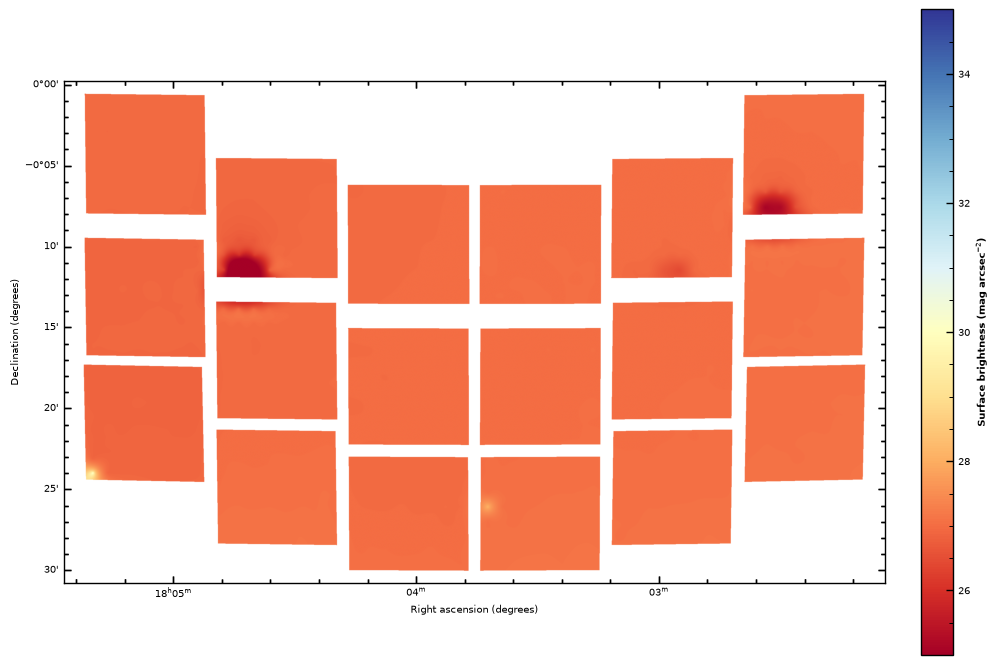

Plot: Stray-light surface brightness flux.
0.0068921241396692375
0.008410303124991176


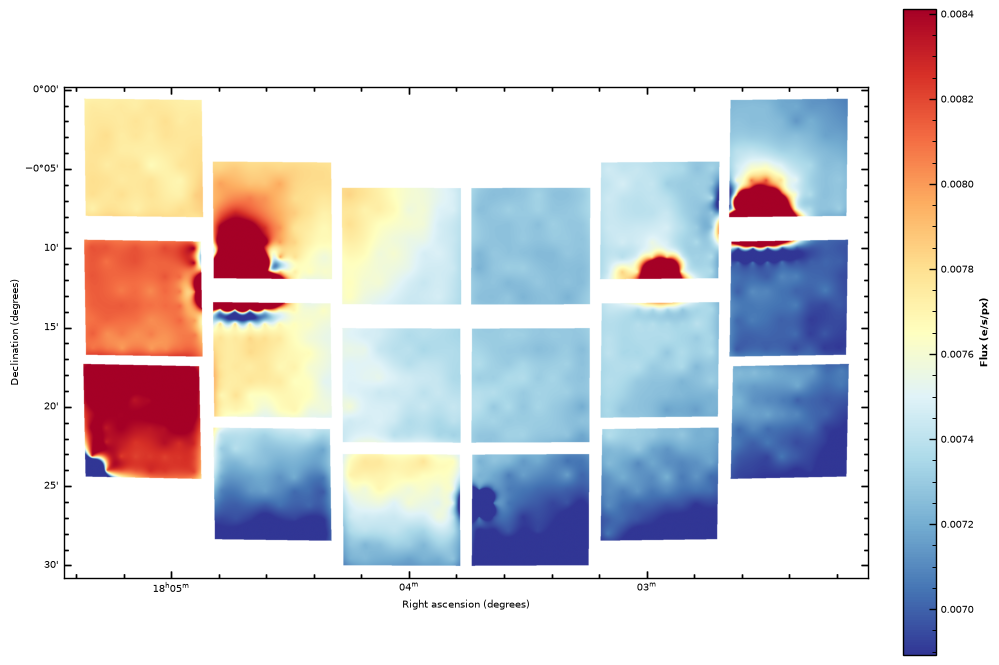

Plot: Main offender map.
15536.0
196912.0
Unique IDs:
[   355   9294  10384  15536  32622 196728 196900 196912 197940 198037
 198141]
Unique IDs with counts > 1:
[   355   9294  10384  15536  32622 196728 196900 196912 197940 198037
 198141]
Simbad cannot find the name of the offender at 269.75436 - -9.770318
Simbad cannot find the name of the offender at 268.18698 - -5.321516
Simbad cannot find the name of the offender at 273.87595 - -5.418018
Simbad cannot find the name of the offender at 274.6143 - 5.3420844
Simbad cannot find the name of the offender at 271.05917 - -1.188153
TYC 5096-97-1
Simbad cannot find the name of the offender at 270.63696 - -0.14191368
Simbad cannot find the name of the offender at 271.17847 - -0.20374422
Simbad cannot find the name of the offender at 270.7377 - -0.20531735
Simbad cannot find the name of the offender at 270.7733 - -0.20267938
Simbad cannot find the name of the offender at 270.6213 - -0.13914013
Main stray-light offenders:

72.48% - (274.61, 5

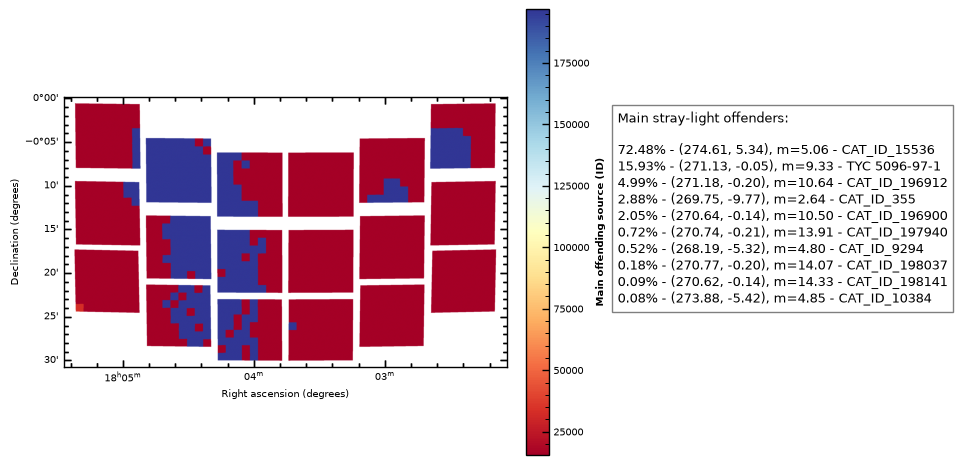

Plot: Source environment map.
SSO body: Sun not found. Skipping
SSO body: Moon not found. Skipping
SSO body: Earth not found. Skipping
SSO body: Mercury not found. Skipping
SSO body: Venus not found. Skipping
SSO body: Mars not found. Skipping
SSO body: Jupiter not found. Skipping
SSO body: Saturn not found. Skipping
SSO body: Uranus not found. Skipping
SSO body: Neptune not found. Skipping
SSO body: Pluto not found. Skipping


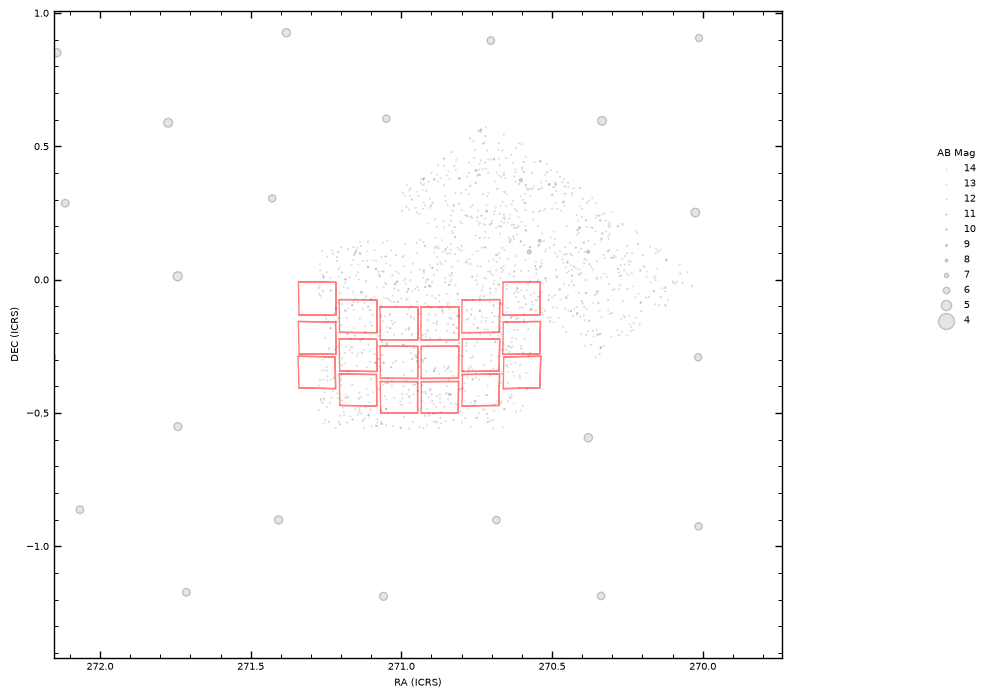

Plot: Location of Main offenders on NDI map.
Unique IDs:
[   355   9294  10384  15536  32622 196728 196900 196912 197940 198037
 198141]
Unique IDs with counts > 1:
[   355   9294  10384  15536  32622 196728 196900 196912 197940 198037
 198141]
Simbad cannot find the name of the offender at 269.75436 - -9.770318
Simbad cannot find the name of the offender at 268.18698 - -5.321516
Simbad cannot find the name of the offender at 273.87595 - -5.418018
Simbad cannot find the name of the offender at 274.6143 - 5.3420844
Simbad cannot find the name of the offender at 271.05917 - -1.188153
TYC 5096-97-1
Simbad cannot find the name of the offender at 270.63696 - -0.14191368
Simbad cannot find the name of the offender at 271.17847 - -0.20374422
Simbad cannot find the name of the offender at 270.7377 - -0.20531735
Simbad cannot find the name of the offender at 270.7733 - -0.20267938
Simbad cannot find the name of the offender at 270.6213 - -0.13914013
Main stray-light offenders:

72.48% - (274.61

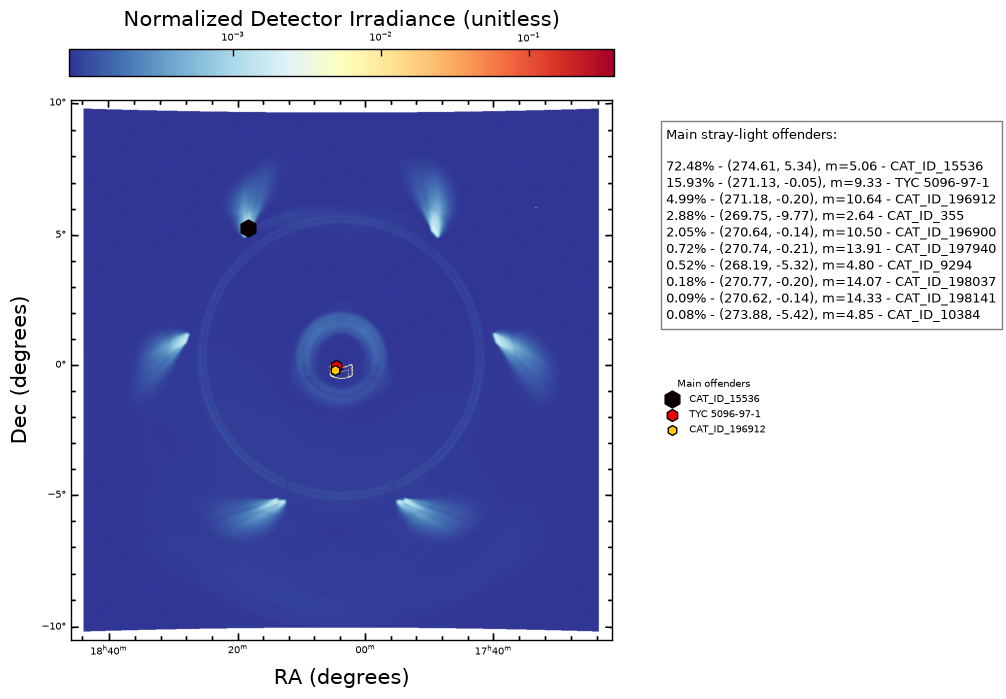

In [6]:
# Here we execute the stray-light method to estimate the backgroud due to out-of-field sources. 
rosalia_stray = rosalia_exposure.straylight()

## About this Notebook

**Author:** Alejandro S. Borlaff - NASA Ames Research Center (Code S) - a.s.borlaff@nasa.gov 

**Updated on** July 28, 2026. 

<table width="100%" style="border:none; border-collapse:collapse;">

  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>